## Least Squares -- An overdetermined system

Suppose we are measuring a road with four points A;B;C and D. We have the following:
 * AD = 89m
 * AC = 67m
 * BD = 53m
 * AB = 35m
 * CD = 20m.
 
We are interested in determining the length of $x_1$ = AB, $x_2$ = BC, and $x_3$ = CD. We have 5
equations and only 3 unknowns. Use least squares to determine what x should be. Are we able to
find $x$ such that $Ax = b$?

### Solution

First, we must write down the relavant equations. From our measurements, we know the following:

\begin{align*}
x_1 + x_2 + x_3 & = 89\\
x_1 + x_2 & = 67\\
x_2 + x_3 & = 53\\
x_1 & = 35\\
x_3 & = 20.
\end{align*}
These equations are in conflict (the 2nd and 4th equations indicate $x_2$ = 32, but the 3rd and 5th equations indicate that $x_2$ = 33. Therefore, we can use least squares to find $x$ that gets $Ax \approx b$:

In [2]:
b = [89; 67; 53; 35; 20]
A = [1 1 1; 1 1 0; 0 1 1; 1 0 0; 0 0 1]

x = A \ b

println("x1 = ", round(x[1],2), "m")
println("x2 = ", round(x[2],2), "m")
println("x3 = ", round(x[3],2), "m")

x1 = 35.12m
x2 = 32.5m
x3 = 20.62m


## Least squares -- Autoregressive model

What if we wanted to do a moving average model, but we didn't have access to the inputs at all?
Instead, we are asked to predict future y values based only on the previous y values. One way to
do this is by using an autoregressive (AR) model, where each output is approximated by a linear
combination of the $\ell$ most recent outputs (excluding the present one):
\begin{align*}
y_t \approx a_1y_{t-1} + a_2y_{t-2} + \dotsm + a_{\ell}y_{t-\ell}.
\end{align*}

Using the same dataset from class 'moving avg data.csv,' plot the true $y$, and on the same axes, also
plot the estimated $\hat{y}$ using the AR model. Use $k = 5$ for the AR model. To quantify the difference
between estimates, also compute $\|y - \hat{y}\|$.

### Solution

We can use the same setup as in the Moving Average example. One key difference is we no longer use the first column of the data, since we don't have access to inputs. The other major difference is how we create the $A$ matrix, which is of the form:

\begin{align*}
\begin{bmatrix}
0 & 0 & 0 & 0 & 0\\
y_1 & 0 & 0 & 0 & 0\\
y_2 & y_1 & 0 & 0 & 0\\
y_3 & y_2 & y_2 & 0 & 0\\
\vdots & & & & \vdots\\
y_{T-1} & y_{T-2} & y_{T-3} & y_{T-4} & y_{T-5}
\end{bmatrix}
\end{align*}


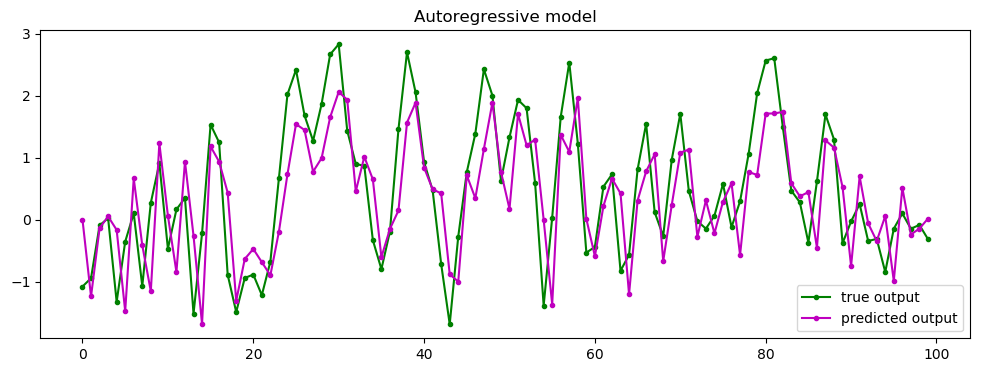


7.436691765656793


In [4]:
# Load the data file (ref: Boyd/263)
raw = readcsv("moving_avg_data.csv");
y = raw[:,2];
T = length(y);

using PyPlot

# generate A matrix. This loop creates A one column at a time.
# The ith column will have 0s until row i+1, then the rest of the 
# entries will by y[1], y[2], ..., y[T-i]
width = 5
A = zeros(T,width)
for i = 1:width
    A[i+1:end,i] = y[1:end-i]
end
wopt = A\y
yest = A*wopt

figure(figsize=(12,4))
plot(y,"g.-",yest,"m.-")
legend(["true output", "predicted output"], loc="lower right");
title("Autoregressive model");
println()
println(norm(yest-y))